In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import lightning as L
from pytorch_lightning.loggers import WandbLogger
from pytorch_optimizer import Lion
from lightning_module import LOfTransformer
from utils.data_utils import *
from of_dataset import OfDataset
from torch.utils.data import random_split


import copy
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt

In [6]:
# Load pseudodata file
f_pd = uproot.open("/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files_v3/Pseudodata_WithSherapaNoReweighting_12May2025_topLogit.root")
t_pd = f_pd["OmniTree"]

# Load pass 190 and isTop flags
pass190_pd = ak.to_numpy(t_pd["pass190"].array())

# Load PD kinematics, dropping top evets
print(f"pd events: {np.sum(pass190_pd)}")
print("We have a fraction {} of good events in pseudodata".format(np.sum(pass190_pd) / len(pass190_pd)))
pd_kinematics, pd_ind = get_kinematics(t_pd, muon_only=False)

pd events: 233729
We have a fraction 1.0 of good events in pseudodata


In [7]:
# Load top MC files
f_top = uproot.open("/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files_v3/ZjetOmnifold_14May2025_Background_Sherpa2212_AllTop_WithTracks_slim_Systematics_topLogit.root")
t_top = f_top["OmniTree"]
# Load Top kinematics
pass190_top = ak.to_numpy(t_top['pass190'].array())
print(f"top events: {np.sum(pass190_top)}")
print("We have a fracion {} of good events in top".format(np.sum(pass190_top) / len(pass190_top)))
top_kinematics, top_ind = get_kinematics(t_top, muon_only=False)

top events: 21017
We have a fracion 0.9988593698018156 of good events in top


In [8]:
pd_obs = np.stack(get_observables(t_pd, ["isTop_logit"]), axis=0)
top_obs = np.stack(get_observables(t_top, ["isTop_logit"]), axis=0)

In [9]:
# Build labels: top is 1 and pd is 0
top_labels = np.ones((len(top_kinematics), 1), dtype=np.float32)
pd_labels0 = np.zeros((len(pd_kinematics), 1), dtype=np.float32)
pd_labels1 = np.ones((len(pd_kinematics), 1), dtype=np.float32)

In [10]:
# Get weights
weight_top = get_observables(t_top, ["weight"])
weight_pd = get_observables(t_pd, ["weight"])

In [11]:
print("Number of PD events: ", len(pd_kinematics))
print("Number of top events: ", len(top_kinematics))
print("Sum of top weights: ", np.sum(weight_top))
print("Sum of pd weights: ", np.sum(weight_pd))
print("Sum of all weights: ", np.sum(weight_top) + np.sum(weight_pd))

Number of PD events:  233729
Number of top events:  21017
Sum of top weights:  524.04987
Sum of pd weights:  233729.0
Sum of all weights:  234253.05


In [14]:
# Create data sets
# We want to add PD twice, once with label = 0 and once with label = 1. Top MC (background) enters with negative weights and label = 1.
kinematics = np.concatenate([top_kinematics, pd_kinematics, pd_kinematics], axis=0)
labels = np.concatenate([top_labels, pd_labels0, pd_labels1], axis=0)
weights = np.concatenate([-1*weight_top, weight_pd, weight_pd], axis=0)
indeces = np.concatenate([top_ind, pd_ind, pd_ind], axis=0)
global_obs = np.concatenate([top_obs, pd_obs, pd_obs], axis=0)

dataset = OfDataset(
    kinematics=kinematics,
    labels=labels,
    weights=weights,
    object_indeces=indeces,
    w1_obs=global_obs,
    n_jets=5,
    max_tracks=264,
)

In [23]:
pd_dataset = OfDataset(
    kinematics=pd_kinematics,
    labels=pd_labels0,
    weights=weight_pd,
    object_indeces=pd_ind,
    w1_obs=pd_obs,
    n_jets=5,
    max_tracks=264,
)
pd_loader = torch.utils.data.DataLoader(
    pd_dataset, 
    batch_size=256,
    shuffle=False,  #  don't shuffle test data
    num_workers=0,
    collate_fn=null_collate,
)

In [16]:
# Get total dataset size
total_size = len(dataset)

# Calculate split sizes (80% train, 20% test)
test_size = int(0.2 * total_size)
train_size = total_size - test_size

print(f"Total dataset size: {total_size}")
print(f"Training size: {train_size}")
print(f"Testing size: {test_size}")

# Split the dataset
train_dataset, test_dataset = random_split(
    dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # For reproducible splits
)

print(f"Train dataset length: {len(train_dataset)}")
print(f"Test dataset length: {len(test_dataset)}")

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=256,  
    shuffle=True,
    num_workers=0,
    collate_fn=null_collate,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=256,
    shuffle=False,  #  don't shuffle test data
    num_workers=0,
    collate_fn=null_collate,
)

Total dataset size: 488475
Training size: 390780
Testing size: 97695
Train dataset length: 390780
Test dataset length: 97695


In [17]:
# Initialize the model and trainer
block_params = {
    "dropout": 0.02,
    "attn_dropout": 0.02,
    "activation_dropout": 0.0,
}
cls_block_params = {
    "dropout": 0.0,
    "attn_dropout": 0.0,
    "activation_dropout": 0.0,
}

model = LOfTransformer(
    input_dim=10,
    seed=42,
    pair_input_dim=4,  # Refers to the number of pairwise features to use
    global_input_dim=1,  # The four features loaded above
    global_embed_dims=[64],  # Global features embedding MLP, layer to produce hidden dim added automatically
    embed_dims=[128, 512, 128],
    pair_embed_dims=[64, 64, 64],
    fc_nodes=[128, 64],  # Classifier head
    num_classes=1,
    num_heads=8,
    num_layers=6,
    num_cls_layers=2,
    block_params=block_params,
    cls_block_params=cls_block_params,
    fc_dropout=0.0,
    activation="gelu",
    remove_self_pair=False,
    max_lr=1e-5,
    min_lr=1e-6,
)

In [19]:
store_location = "./checkpoints/top-subtraction/test-002"

# logger = WandbLogger(
#     project="top-subtraction",
#     name="top-classifier-test",
#     save_dir=store_location,
# )

lr_monitor = L.pytorch.callbacks.LearningRateMonitor(logging_interval="step")

checkpoints = L.pytorch.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filename="{epoch:02d}-{step:06d}-{val_loss:.1f}",
    save_top_k=1,
    mode="min",
    dirpath=store_location,
)

early_stopping = L.pytorch.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
)

trainer = L.Trainer(
    accelerator="auto",
    devices=1,
    logger=None,
    callbacks=[lr_monitor, checkpoints, early_stopping],
    default_root_dir=store_location,
    max_epochs=2,
    enable_progress_bar=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [20]:
trainer.fit(model, train_loader, test_loader)

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:639: Checkpoint directory /global/cfs/cdirs/m3246/twamorka/zjets_omnifold/checkpoints/top-subtraction/test-002 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type              | Params
------------------------------------------------
0 | criterion | BCEWithLogitsLoss | 0     
1 | model     | OfTransformer     | 1.8 M 
2 | val_auc   | BinaryAUROC       | 0     
3 | test_auc  | BinaryAUROC       | 0     
------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.095     Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:232: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


In [21]:
model = LOfTransformer.load_from_checkpoint(
        "checkpoints/top-subtraction/test-002/epoch=01-step=003054-val_loss=0.7.ckpt",
    input_dim=10,
    seed=42,
    pair_input_dim=4,  # Refers to the number of pairwise features to use
    global_input_dim=1,  # The four features loaded above
    global_embed_dims=[
        64
    ],  # Global features embedding MLP, layer to produce hidden dim added automatically
    embed_dims=[128, 512, 128],
    pair_embed_dims=[64, 64, 64],
    fc_nodes=[128, 64],  # Classifier head
    num_classes=1,
    num_heads=8,
    num_layers=6,
    num_cls_layers=2,
    block_params=block_params,
    cls_block_params=cls_block_params,
    fc_dropout=0.0,
    activation="gelu",
    remove_self_pair=False,
    max_lr=1e-5,
    min_lr=1e-6,
)

/global/homes/t/twamorka/.conda/envs/zjets/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:56: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [33]:
preds_pd = trainer.predict(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
SLURM auto-requeueing enabled. Setting signal handlers.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [34]:
preds_pd = torch.cat([pred.cpu().flatten() for pred in preds_pd])

In [37]:
(preds_pd)

tensor([-0.0012, -0.0013, -0.0012,  ..., -0.0013, -0.0013, -0.0013])

(array([5.7750e+03, 5.0853e+04, 2.8206e+04, 8.9060e+03, 2.8950e+03,
        7.8500e+02, 2.0300e+02, 5.5000e+01, 1.6000e+01, 1.0000e+00]),
 array([-0.00136092, -0.00132094, -0.00128095, -0.00124097, -0.00120098,
        -0.00116099, -0.00112101, -0.00108102, -0.00104104, -0.00100105,
        -0.00096107]),
 <BarContainer object of 10 artists>)

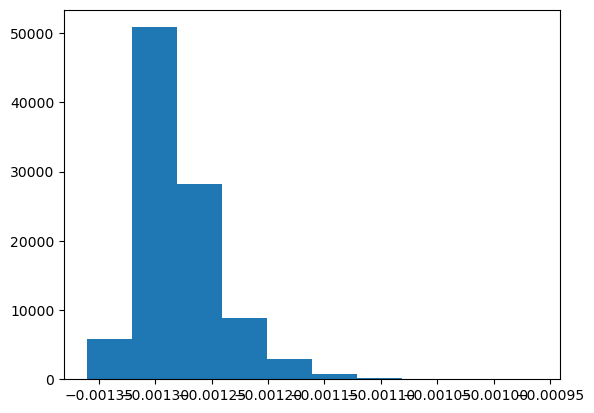

In [36]:
plt.hist(preds_pd)

In [29]:
pd_m1_pt = np.exp(pd_kinematics[:, 0, 0])
top_m1_pt = np.exp(top_kinematics[:, 0, 0])

/tmp/ipykernel_1254194/1869659420.py:5: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


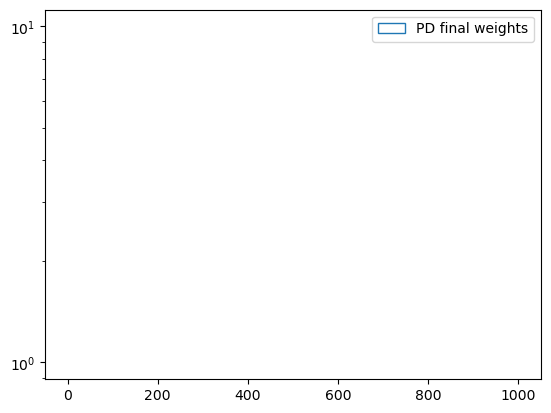

In [32]:
bins_m1pt = np.linspace(0,1e3, 50)
# plt.hist(pd_m1_pt,bins=bins_m1pt, weights=weight_pd,density=False, histtype="step", label="PD init weights")
plt.hist(pd_m1_pt,weights=preds_pd,bins=bins_m1pt, density=False, histtype="step", label="PD final weights")

plt.yscale('log')
# plt.xscale('log')
plt.legend()